In [28]:
import pandas as pd

In [29]:
import numpy as np

In [30]:
import matplotlib.pyplot as plt

In [31]:
import seaborn as sns

In [32]:
from sklearn.preprocessing import MinMaxScaler

In [33]:
%matplotlib inline

In [34]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/raw/vgchartz-2024.csv")

In [35]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [36]:
df.dtypes # check data types

img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object

In [37]:
df = df.drop(['img','last_update'], axis=1) # remove columns

In [38]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06


In [39]:
df = df.rename(columns={"title": "Game Title", "console": "Console",
                        "genre": "Genre", "publisher": "Publisher",
                        "developer": "Developer", "critic_score": "Critic Score",
                        "total_sales": "Sales", "na_sales": "North American Sales",
                        "jp_sales": "Japanese Sales", "pal_sales": "EU Sales", 
                        "other_sales": "Other Sales", "release_date": "Release Date",})  # rename columns

In [40]:
df.shape # check dimentions

(64016, 12)

In [41]:
df.count() # count rows

Game Title              64016
Console                 64016
Genre                   64016
Publisher               64016
Developer               63999
Critic Score             6678
Sales                   18922
North American Sales    12637
Japanese Sales           6726
EU Sales                12824
Other Sales             15128
Release Date            56965
dtype: int64

In [42]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)   #check duplicates 

number of duplicate rows:  (21, 12)


In [43]:
df = df.drop_duplicates() # drop duplicates

In [44]:
print(df.isnull().sum()) # missing values ( null )

Game Title                  0
Console                     0
Genre                       0
Publisher                   0
Developer                  17
Critic Score            57317
Sales                   45076
North American Sales    51358
Japanese Sales          57272
EU Sales                51171
Other Sales             48867
Release Date             7051
dtype: int64


In [45]:
# 1. Drop rows with missing target
df = df.dropna(subset=['Sales'])

# 2. Fill categorical with "Unknown"
for col in ['Publisher','Developer','Genre','Console']:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# 3. Fill regional sales with 0
for col in ['North American Sales','Japanese Sales','EU Sales','Other Sales']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 4. Critic Score -> fill with mean
if 'Critic Score' in df.columns:
    df['Critic Score'] = df['Critic Score'].fillna(df['Critic Score'].mean())

# 5. Release Date -> convert to year, fill missing with median
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year
df['Release Year'] = df['Release Year'].fillna(df['Release Year'].median())

In [46]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Date,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015.0


In [47]:
df.count() # count rows

Game Title              18919
Console                 18919
Genre                   18919
Publisher               18919
Developer               18919
Critic Score            18919
Sales                   18919
North American Sales    18919
Japanese Sales          18919
EU Sales                18919
Other Sales             18919
Release Date            18829
Release Year            18919
dtype: int64

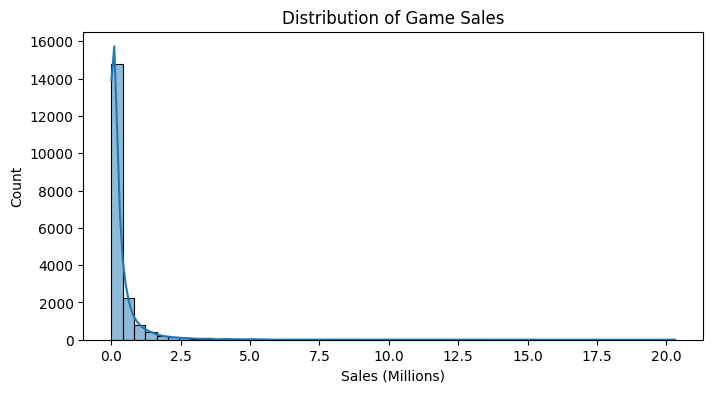

In [48]:
# Histogram for Game Sales Distribution 

plt.figure(figsize=(8,4))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Distribution of Game Sales")
plt.xlabel("Sales (Millions)")
plt.ylabel("Count")
plt.show()

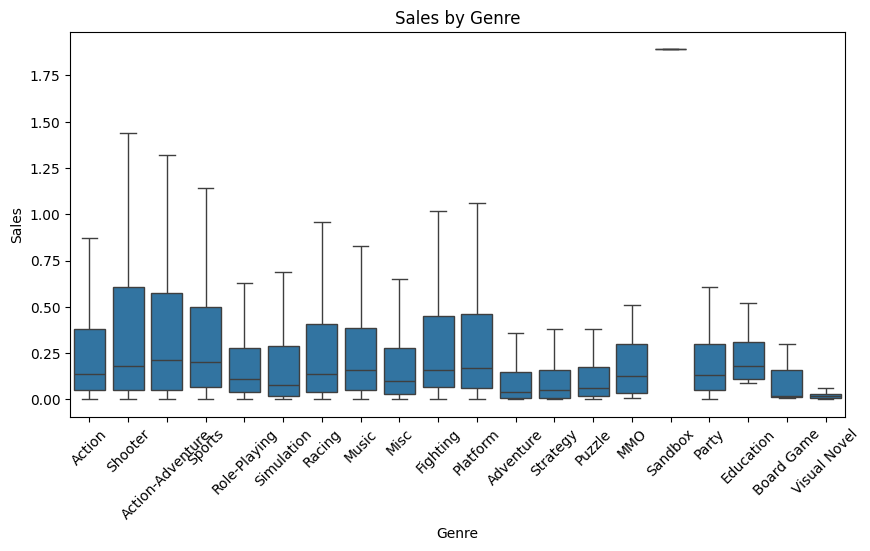

In [49]:
# Boxplot for Sales by Genre

plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='Sales', data=df, showfliers=False)
plt.xticks(rotation=45)
plt.title("Sales by Genre")
plt.show()

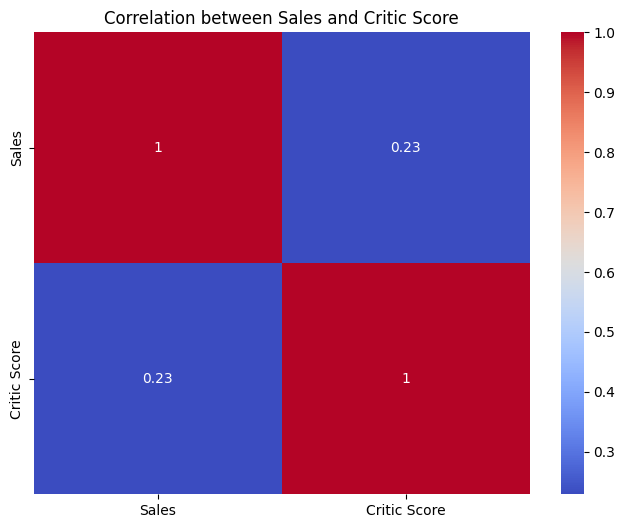

In [50]:
# Heatmap between Sales and Critic Score 
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Critic Score']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Sales and Critic Score")
plt.show()

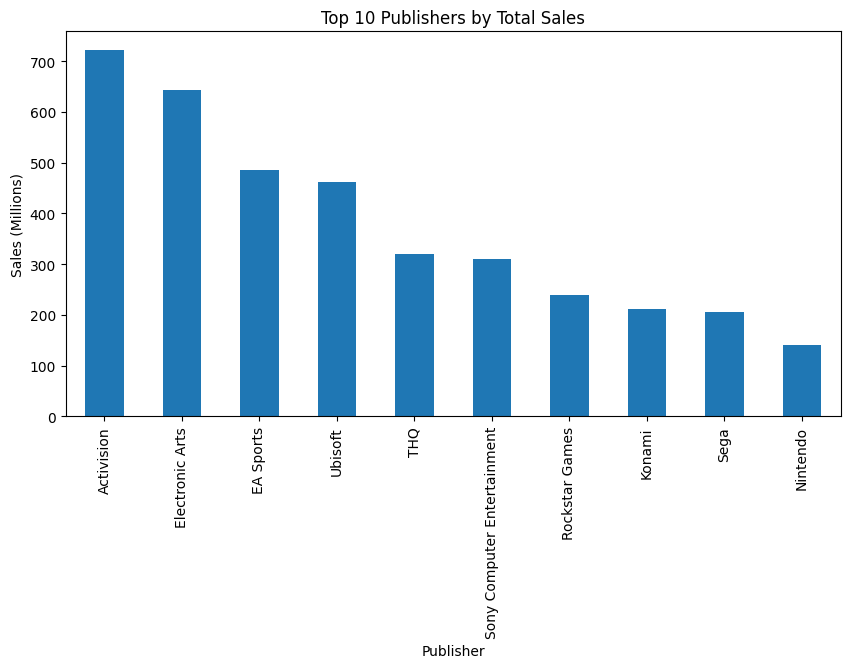

In [51]:
#Barplot for top 10 Publishers by Sales
top_publishers = df.groupby('Publisher')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_publishers.plot(kind='bar')
plt.title("Top 10 Publishers by Total Sales")
plt.ylabel("Sales (Millions)")
plt.show()

In [52]:
# Top publisher = Good Sales
top_publishers = ['Nintendo', 'Electronic Arts', 'Activision', 'Sony Computer Entertainment', 'Ubisoft']

df['Big Publisher'] = df['Publisher'].apply(lambda x: 1 if x in top_publishers else 0)

In [53]:
# One-hot encode Genre & Platform
df = pd.get_dummies(df, columns=['Genre','Console'], drop_first=True)

# For Publisher/Developer, keep top 30 and label others as "Other"
def cap_top(series, n=30):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "Other")

df['Publisher'] = cap_top(df['Publisher'])
df['Developer'] = cap_top(df['Developer'])

# One-hot encode after capping
df = pd.get_dummies(df, columns=['Publisher','Developer'], drop_first=True)

In [54]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Date,Release Year,Big Publisher,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Grand Theft Auto V,9.40000,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013.0,0,...,True,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,9.70000,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014.0,0,...,True,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,9.60000,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002.0,0,...,True,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,7.10189,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013.0,0,...,True,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,8.10000,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015.0,1,...,True,False,False,False,False,False,False,False,False,False


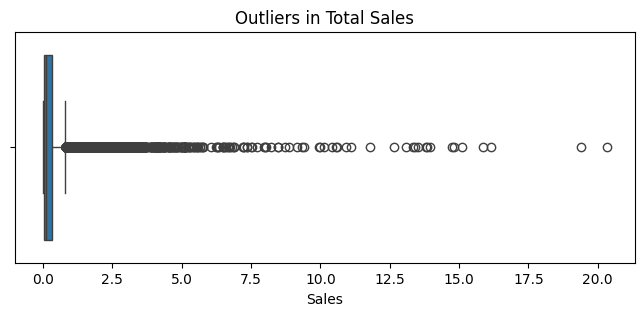

In [55]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Total Sales")
plt.show()

In [56]:
# Scale Critic Score between 0-1 ( Normalization )
scaler = MinMaxScaler()

# Scale critic score only (keep Sales as original for prediction target)
df['Critic Score'] = scaler.fit_transform(df[['Critic Score']])

In [57]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Date,Release Year,Big Publisher,...,Developer_Other,Developer_Sega,Developer_Square Enix,Developer_THQ,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts
0,Grand Theft Auto V,0.933333,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013.0,0,...,True,False,False,False,False,False,False,False,False,False
1,Grand Theft Auto V,0.966667,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014.0,0,...,True,False,False,False,False,False,False,False,False,False
2,Grand Theft Auto: Vice City,0.955556,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002.0,0,...,True,False,False,False,False,False,False,False,False,False
3,Grand Theft Auto V,0.677988,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013.0,0,...,True,False,False,False,False,False,False,False,False,False
4,Call of Duty: Black Ops 3,0.788889,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015.0,1,...,True,False,False,False,False,False,False,False,False,False


In [58]:
df = df[df['Sales'] > 0].reset_index(drop=True) #drop 0 valued sales for better accuracy

In [59]:
df.shape # check dimentions

(17567, 127)

In [60]:
# Scale Sales & Regional Sales between 0-1 
# Define the sales columns 
sales_cols = ['Sales', 'North American Sales', 'EU Sales', 'Japanese Sales', 'Other Sales']

scaler = MinMaxScaler()

# Fit + transform the sales columns
df[sales_cols] = scaler.fit_transform(df[sales_cols])

In [61]:
# Create decade column
df['Decade'] = (df['Release Year'] // 10) * 10

# Percentages of sales per region 
df['NA Share'] = df['North American Sales'] / df['Sales']
df['EU Share'] = df['EU Sales'] / df['Sales']
df['JP Share'] = df['Japanese Sales'] / df['Sales']
df['Other Share'] = df['Other Sales'] / df['Sales']

# New Game ?
df['Is Recent'] = df['Release Year'].apply(lambda x: 1 if x >= 2015 else 0)

In [62]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Date,Release Year,Big Publisher,...,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013-09-17,2013.0,0,...,False,False,False,False,2010.0,0.652664,1.000000,0.464789,1.000000,0
1,Grand Theft Auto V,0.966667,0.954210,0.620902,0.281690,0.985787,0.967949,2014-11-18,2014.0,0,...,False,False,False,False,2010.0,0.650697,1.033092,0.295208,1.014398,0
2,Grand Theft Auto: Vice City,0.955556,0.794682,0.861680,0.220657,0.557360,0.570513,2002-10-28,2002.0,0,...,False,False,False,False,2000.0,1.084308,0.701362,0.277667,0.717913,0
3,Grand Theft Auto V,0.677988,0.780404,0.928279,0.028169,0.541117,0.455128,2013-09-17,2013.0,0,...,False,False,False,False,2010.0,1.189485,0.693381,0.036095,0.583196,0
4,Call of Duty: Black Ops 3,0.788889,0.742491,0.633197,0.192488,0.614213,0.782051,2015-11-06,2015.0,1,...,False,False,False,False,2010.0,0.852800,0.827233,0.259246,1.053280,1


In [64]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/VGChartz_2024_Cleaned.csv", index=False)